In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.model_data import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
data=pd.read_csv('Data\dati_imputati.csv', low_memory=False)
data.head()

,subject_id,los_hospital_day,hospmort28day,icu_outtime,los_icu_day,weight,height,ph,paco2,pao2,...,hospmort90day,bmi,ibw,comorb_score,icumort,hospmort,icu_day_start,vent_mode,adjust_tidal_volume,weaning_success
0,10001884,12.36,1,2131-01-20 08:27:30,9.17,65.0,157.0,7.42,53.0,69.0,...,1,26.37,49.686,5.0,1,1,2131-01-13 00:20:05,APV (cmv),8.73,1
1,10001884,12.36,1,2131-01-20 08:27:30,9.17,65.0,157.0,7.42,53.0,69.0,...,1,26.37,49.686,5.0,1,1,2131-01-13 04:20:05,APV (cmv),8.43,1
2,10001884,12.36,1,2131-01-20 08:27:30,9.17,65.0,157.0,7.42,53.0,69.0,...,1,26.37,49.686,5.0,1,1,2131-01-13 08:20:05,APV (cmv),8.07,1
3,10001884,12.36,1,2131-01-20 08:27:30,9.17,65.0,157.0,7.42,53.0,69.0,...,1,26.37,49.686,5.0,1,1,2131-01-13 12:20:05,APV (cmv),8.88,1
4,10001884,12.36,1,2131-01-20 08:27:30,9.17,65.0,157.0,7.42,53.0,69.0,...,1,26.37,49.686,5.0,1,1,2131-01-13 16:20:05,APV (cmv),6.94,1


## Demografia
#### Età

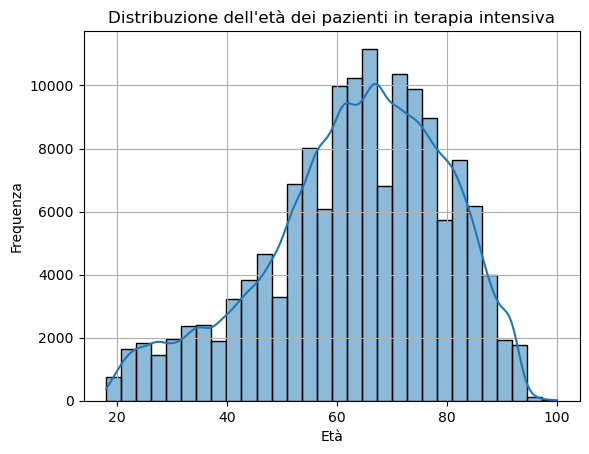

In [3]:
sns.histplot(data['age'], bins=30, kde=True)
plt.title('Distribuzione dell\'età dei pazienti in terapia intensiva')
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.grid()
plt.show()

Tasso di mortalità per sesso:
gender
F    20.420803
M    18.032920
Name: icumort, dtype: float64


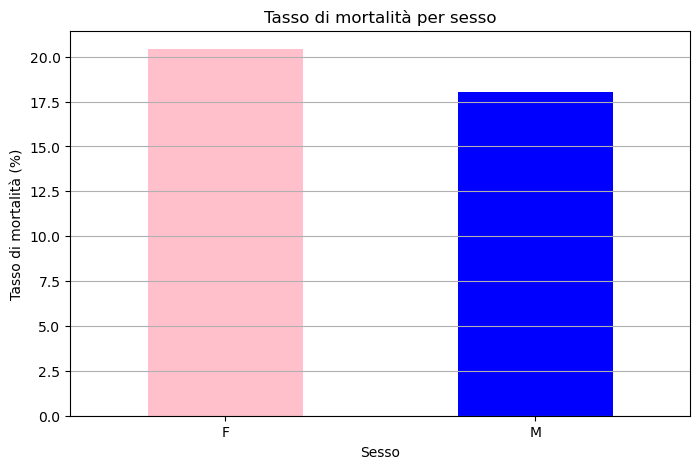

In [4]:
# Tasso di mortalità per sesso
mortality_by_gender = data.groupby('gender')['icumort'].mean() * 100
print('Tasso di mortalità per sesso:')
print(mortality_by_gender)

# Grafico a barre per mortalità per sesso
plt.figure(figsize=(8, 5))
mortality_by_gender.plot(kind='bar', color=['pink', 'blue'])
plt.title('Tasso di mortalità per sesso')
plt.xlabel('Sesso')
plt.ylabel('Tasso di mortalità (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Tasso di mortalità in terapia intensiva: 19.00%
Tasso di mortalità ospedaliera: 22.97%
Tasso di mortalità a 90 giorni: 29.28%
Tasso di mortalità per sesso:
          icumort   hospmort  hospmort90day
gender                                     
F       20.420803  24.494782      31.090184
M       18.032920  21.920848      28.037915


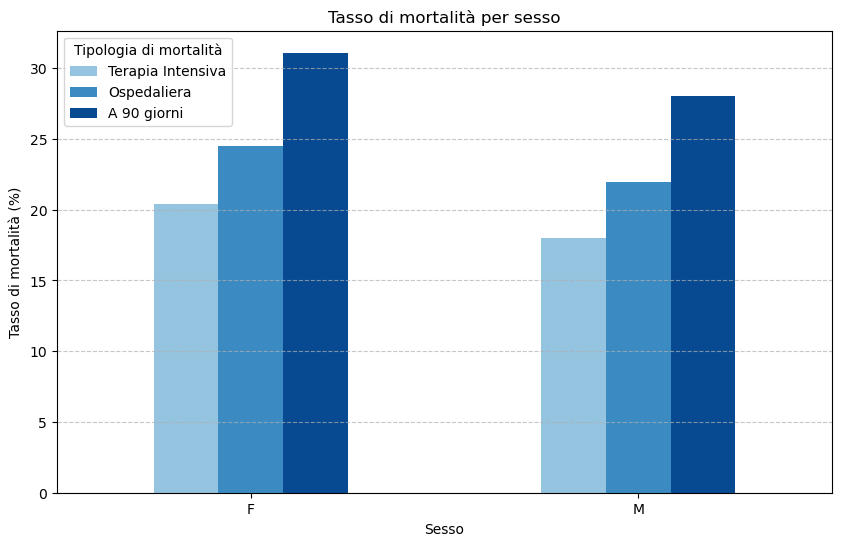

In [5]:
icumort_rate = data['icumort'].mean() * 100
hospmort_rate = data['hospmort'].mean() * 100
mort90day_rate = data['hospmort90day'].mean() * 100

print(f'Tasso di mortalità in terapia intensiva: {icumort_rate:.2f}%')
print(f'Tasso di mortalità ospedaliera: {hospmort_rate:.2f}%')
print(f'Tasso di mortalità a 90 giorni: {mort90day_rate:.2f}%')

mortality_by_gender = data.groupby('gender')[['icumort', 'hospmort', 'hospmort90day']].mean() * 100
print('Tasso di mortalità per sesso:')
print(mortality_by_gender)

# 3. Grafico a barre con sfumature di blu
n_cols = mortality_by_gender.shape[1]  # numero di colonne (icumort, hospmort, hospmort90day)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, n_cols))  # sfumature dal blu medio allo scuro

ax = mortality_by_gender.plot(
    kind='bar',
    figsize=(10, 6),
    color=colors
)

plt.title('Tasso di mortalità per sesso')
plt.xlabel('Sesso')
plt.ylabel('Tasso di mortalità (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Tipologia di mortalità", labels=['Terapia Intensiva', 'Ospedaliera', 'A 90 giorni'])
plt.show()

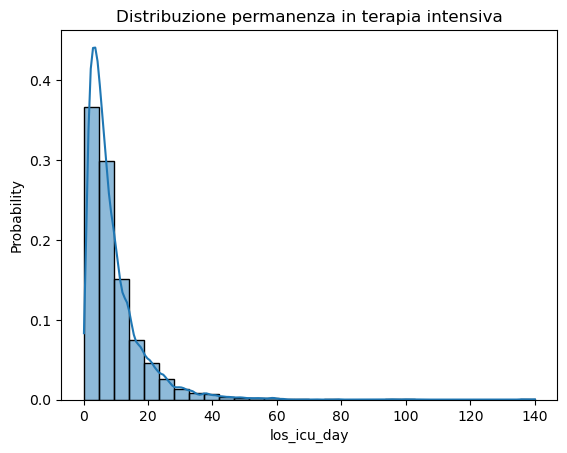

9.153345423452995


In [6]:
sns.histplot(data.los_icu_day, stat="probability", bins=30, kde=True)
plt.title("Distribuzione permanenza in terapia intensiva")
plt.show()

print(data.los_icu_day.mean())

In [7]:
patients = data.drop_duplicates(subset='subject_id', keep='first')
print("{:<30} {}".format("Included patients", patients.subject_id.nunique()))
print("{:<30} {}".format("Included stays", data.shape[0]))
print("{:<30} {:.2f} ± ({:.2f}-{:.2f})".format(
    "Age, years median (q1-q3)",
    patients.age.median(),
    patients.age.quantile(.25),
    patients.age.quantile(.75)
))
print("{:<30} {:.2f} ±{:.2f}".format(
    "Adm. Weight mean ± std",
    patients.weight.mean(),
    patients.weight.std()
))
print("{:<30} {:.2f} ±{:.2f}".format(
    "Pred. IBW mean ± std",
    patients.ibw.mean(),
    patients.ibw.std()
))
gender_counts = patients.gender.value_counts
print("{:<30} {} ({:.2f}%)".format("Female", (patients.gender == 'F').sum(), 100*(patients.gender == 'F').sum() / patients.shape[0]))
print("{:<30} {} ({:.2f}%)".format("Male", (patients.gender == 'M').sum(), 100*(patients.gender == 'M').sum() / patients.shape[0]))
print("{:<30} {:.2f}%".format("90-day mortality", (patients.hospmort90day == 't').sum() / patients.shape[0] / 0.01))
print("{:<30} {:.2f}%".format("hosp mortality", (patients.hospmort == 't').sum() / patients.shape[0] / 0.01))
los_icu_median_days = patients.los_icu_day.median()
los_icu_q1_days =  patients.los_icu_day.quantile(.25)
los_icu_q3_days =  patients.los_icu_day.quantile(.75)
print("{:<30} {:.2f} ({:.2f}-{:.2f})".format(
    "LOS ICU median (q1-q3)",
    los_icu_median_days,
    los_icu_q1_days,
    los_icu_q3_days
))
los_hosp_median_days = patients.los_hospital_day.median()
los_hosp_q1_days =  patients.los_hospital_day.quantile(.25)
los_hosp_q3_days =  patients.los_hospital_day.quantile(.75)
print("{:<30} {:.2f} ({:.2f}-{:.2f})".format("LOS hosp median (q1-q3)", los_hosp_median_days, los_hosp_q1_days, los_icu_q3_days))
print("{:<30} {:.1f} ±{:.2f}".format("PEEP cmH2O mean ±std", data.peep.mean(), data.peep.std()))
print("{:<30} {:.2f} ±{:.2f}".format("FiO2, % mean ±std", data.fio2.mean(), data.fio2.std()))
data['vt_mlkg'] = data.tidal_volume / data.ibw
print("{:<30} {:.2f} ±{:.2f}".format("Vt, mL/kg (PIBW) mean ±std", data['vt_mlkg'].mean(), data['vt_mlkg'].std()))
print("{:<30} {:.2f} ±{:.2f}".format(
    "SOFA points @ adm. mean ±std",
    patients.sofa.mean(),
    patients.sofa.std()
))

Included patients              16061
Included stays                 145022
Age, years median (q1-q3)      66.00 ± (55.00-76.00)
Adm. Weight mean ± std         84.30 ±23.76
Pred. IBW mean ± std           64.06 ±10.79
Female                         6113 (38.06%)
Male                           9948 (61.94%)
90-day mortality               0.00%
hosp mortality                 0.00%
LOS ICU median (q1-q3)         3.63 (1.89-7.73)
LOS hosp median (q1-q3)        9.32 (5.76-7.73)
PEEP cmH2O mean ±std           7.2 ±3.37
FiO2, % mean ±std              49.84 ±16.61
Vt, mL/kg (PIBW) mean ±std     7.48 ±1.93
SOFA points @ adm. mean ±std   11.67 ±3.36


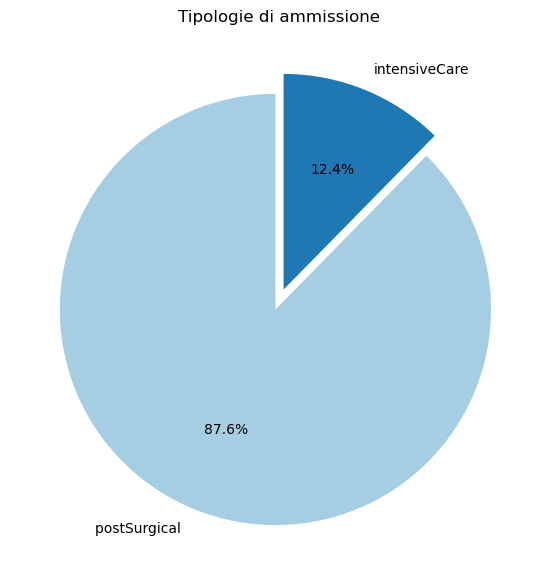

In [8]:
admission_counts = data['admission_type'].value_counts()

# Grafico a torta
plt.figure(figsize=(7, 7))
plt.pie(
    admission_counts, 
    labels=admission_counts.index,
    explode=[0.05] * len(admission_counts) ,
    autopct='%1.1f%%',    # percentuali
    startangle=90,        # inizio dall'alto
    colors=plt.cm.Paired.colors  # palette di colori
)
plt.title('Tipologie di ammissione')
plt.show()

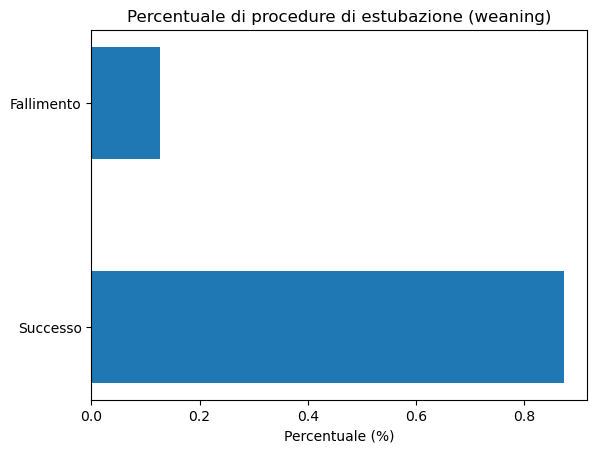

In [11]:
w = data.groupby('subject_id')['weaning_success'].last().value_counts(normalize=True)
plt.barh(['Successo','Fallimento'], w.values, height=0.5)
plt.title("Percentuale di procedure di estubazione (weaning)")
plt.xlabel("Percentuale (%)")
plt.show()

# Traiettorie Analisi

In [3]:
from sklearn.cluster import KMeans
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

discrete_action = np.load("data/actions/1dactions.npy")
action = np.load("data/actions/3dactions_not_binned.npy")
done_flag = np.load("data/done_flags/done_flags.npy")
reward = np.load("data/rewards/rewards_with_intermediate_fixed.npy")
state = np.load("data/states/raw_states.npy")

data = pd.DataFrame({
    #"state": state,
    "discrete_state": KMeans(660).fit(state).labels_,
    "discrete_action": discrete_action,
    #"action": action,
    "reward": reward,
    "done_flag": done_flag
})
data

,discrete_state,discrete_action,reward,done_flag
0,349,121,0,0
1,349,121,0,0
2,6,121,0,0
3,349,121,0,0
4,349,121,0,0
...,...,...,...,...
145017,421,121,0,0
145018,421,120,0,0
145019,421,121,0,0
145020,421,121,0,0


In [101]:
n_states=662
n_actions=7**3
n_clusters_states=660
alive_state=660
died_state=661
data.loc[(data['done_flag']==1) & (data['reward']==1),'discrete_state']=alive_state
data.loc[(data['done_flag']==1) & (data['reward']==-1),'discrete_state']=died_state

data['next_state'] = data['discrete_state'].shift(-1).ffill().astype(int)
data.loc[(data['done_flag']==1) & (data['reward']==1),'next_state']=alive_state
data.loc[(data['done_flag']==1) & (data['reward']==-1),'next_state']=died_state

assert (data.loc[(data['done_flag']==1) & (data['reward']==1),'next_state'] == data.loc[(data['done_flag']==1) & (data['reward']==1),'discrete_state']).all()
assert (data.loc[(data['done_flag']==1) & (data['reward']==-1),'next_state'] == data.loc[(data['done_flag']==1) & (data['reward']==-1),'discrete_state']).all()

traj = data

Numero totale di transizioni: 145022
Numero di episodi/trajectories: 16061
Lunghezza media episodio: 8.029450221032315


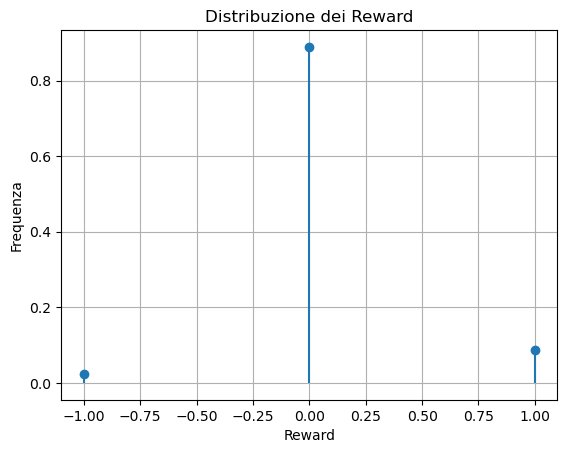

In [ ]:
print(f"Numero totale di transizioni: {len(data)}")
print(f"Numero di episodi/trajectories: {data["done_flag"].sum()}")

lunghezze_episodi = []
lunghezza_corrente = 0

# Itera attraverso i dati
for valore in data['done_flag']:
    if valore == 1:
        lunghezze_episodi.append(lunghezza_corrente)  # Aggiungi la lunghezza dell'episodio
        lunghezza_corrente = 0  # Reset della lunghezza corrente
    else:
        lunghezza_corrente += 1  # Incrementa la lunghezza corrente

# Calcola la lunghezza media
lunghezza_media = np.mean(lunghezze_episodi) if lunghezze_episodi else 0

print(f"Lunghezza media episodio: {lunghezza_media}")

reward_freq = data['reward'].value_counts(normalize=True)

plt.vlines(reward_freq.index, 0, reward_freq.values)
plt.plot(reward_freq.index, reward_freq.values, 'o')

plt.title('Distribuzione dei Reward')
plt.xlabel('Reward')
plt.ylabel('Frequenza')
plt.grid()
#plt.xticks([-1, 0, 1])  # Imposta i tick dell'asse x per i valori interi
plt.show()

Numero totale di transizioni: 145022
Numero di episodi/trajectories: 16061
rewards
 1.000000e+00    0.085911
 9.216653e-10    0.032161
 7.456157e-10    0.027506
 1.273764e-09    0.027410
 5.695661e-10    0.026251
                   ...   
-4.355912e-04    0.000007
 8.711795e-04    0.000007
-3.811427e-04    0.000007
-8.167304e-04    0.000007
 1.034525e-03    0.000007
Name: proportion, Length: 577, dtype: float64


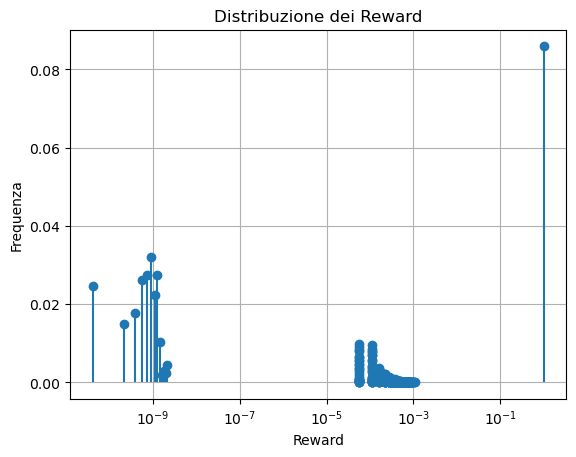

In [24]:
data2 = pd.read_csv("Data/traj_ACT_DIS_STATE_DIS_660_INT_REW.csv")

print(f"Numero totale di transizioni: {len(data2)}")
print(f"Numero di episodi/trajectories: {data2['done_flags'].sum()}")

lunghezze_episodi = []
lunghezza_corrente = 0

reward_freq = data2['rewards'].value_counts(normalize=True)
print(reward_freq)

plt.vlines(reward_freq.index, 0, reward_freq.values)
plt.plot(reward_freq.index, reward_freq.values, 'o')

plt.title('Distribuzione dei Reward')
plt.xscale('log')
plt.xlabel('Reward')
plt.ylabel('Frequenza')
plt.grid()
#plt.xticks([-1, 0, 1])  # Imposta i tick dell'asse x per i valori interi
plt.show()

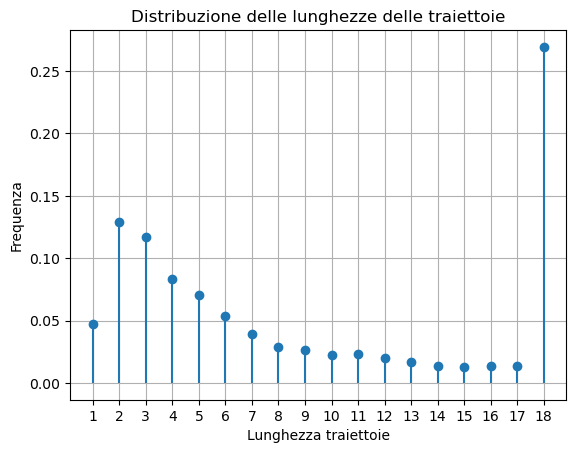

In [35]:
reward_freq = pd.Series(lunghezze_episodi).value_counts(normalize=True)

plt.vlines(reward_freq.index+1, 0, reward_freq.values)
plt.plot(reward_freq.index+1, reward_freq.values, 'o')

plt.title('Distribuzione delle lunghezze delle traiettoie')
plt.xlabel('Lunghezza traiettoie')
plt.ylabel('Frequenza')
plt.grid()
plt.xticks(reward_freq.index+1)  # Imposta i tick dell'asse x per i valori interi
plt.show()

Ho visitato 299 azioni su 343
Ho visitato 662 stati su 662


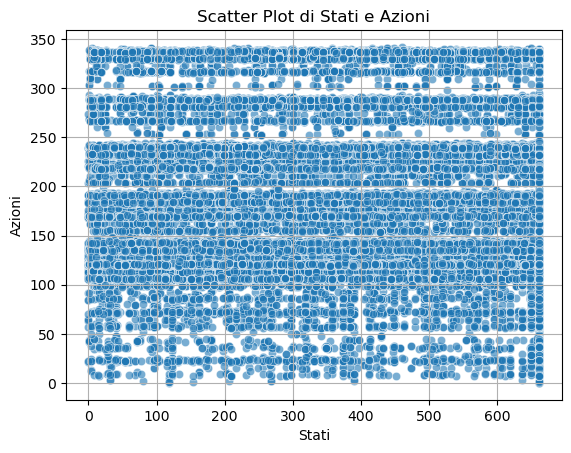

In [17]:
import seaborn as sns 

print(f"Ho visitato {data['discrete_action'].nunique()} azioni su 343")
# if data['discrete_action'].nunique() != n_actions:
#     missing_action = [i for i in range(0, 7**3 + 1) if i not in list(data['discrete_action'])]
#     print(f"Non ho visitato i seguenti stati: {missing_action}")
print(f"Ho visitato {data['discrete_state'].nunique()} stati su 662")

sns.scatterplot(x='discrete_state', y='discrete_action', data=data, alpha=0.6)
plt.title('Scatter Plot di Stati e Azioni')
plt.xlabel('Stati')
plt.ylabel('Azioni')
# plt.xlim(0, 343)  # Limiti per l'asse x
# plt.ylim(0, 662)  # Limiti per l'asse y
plt.grid()
plt.show()

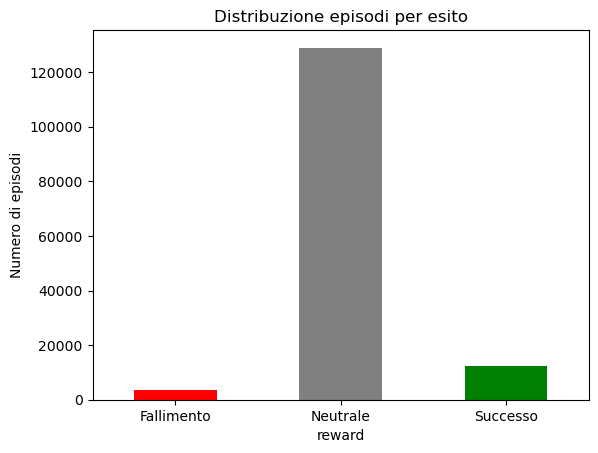

In [38]:
import matplotlib.pyplot as plt

# Conteggio episodi per reward finale
data['reward'].value_counts().sort_index().plot(kind='bar', color=['red','gray','green'])
plt.xticks([0,1,2], ['Fallimento', 'Neutrale', 'Successo'], rotation=0)
plt.ylabel("Numero di episodi")
plt.title("Distribuzione episodi per esito")
plt.show()


In [102]:
val=0
ep = []
for num, valore in enumerate(data['done_flag']):
    ep.append(val) 
    if valore == 1:
        val +=1
data['ep']=ep

In [103]:
ep_idx_succ = data[data['reward']==1]['ep']
ep_idx_fall = data[data['reward']==-1]['ep']
success_episodes = data[data['ep'].isin(ep_idx_succ)]
failure_episodes = data[data['ep'].isin(ep_idx_fall)]
# Controlla le azioni più frequenti nei successi
print(success_episodes['discrete_action'].value_counts().head(8))
print(failure_episodes['discrete_action'].value_counts().head(10))

discrete_action
121    10558
120    10119
135     6428
134     4945
142     4472
122     3617
141     3376
106     3007
Name: count, dtype: int64
discrete_action
120    3949
121    3809
135    1969
134    1718
239    1647
106    1535
122    1270
240    1238
142    1214
141    1140
Name: count, dtype: int64


In [60]:
"""Esplorazione vs exploitazione

 Misura la varietà di azioni per stato (entropia delle azioni).

 Controlla se ci sono traiettorie ad alto ritorno e traiettorie casuali.

 Metriche di diversità: SACo, TQ (se disponibili).

Visualizzazioni consigliate:

Grafico a barre o boxplot della distribuzione delle azioni.

Istogramma dei ritorni totali per traiettoria
"""
entropia_per_stato = data.groupby('discrete_state')['discrete_action'].value_counts(normalize=True).unstack().fillna(0)
entropia = - (entropia_per_stato * np.log(entropia_per_stato + 1e-10)).sum(axis=1)

# Aggiungi l'entropia al DataFrame
print(data['discrete_state'].map(entropia))

0         3.144304
1         3.144304
2         3.395587
3         3.144304
4         3.144304
            ...   
145017    2.961763
145018    2.961763
145019    2.961763
145020    2.961763
145021    3.933517
Name: discrete_state, Length: 145022, dtype: float64


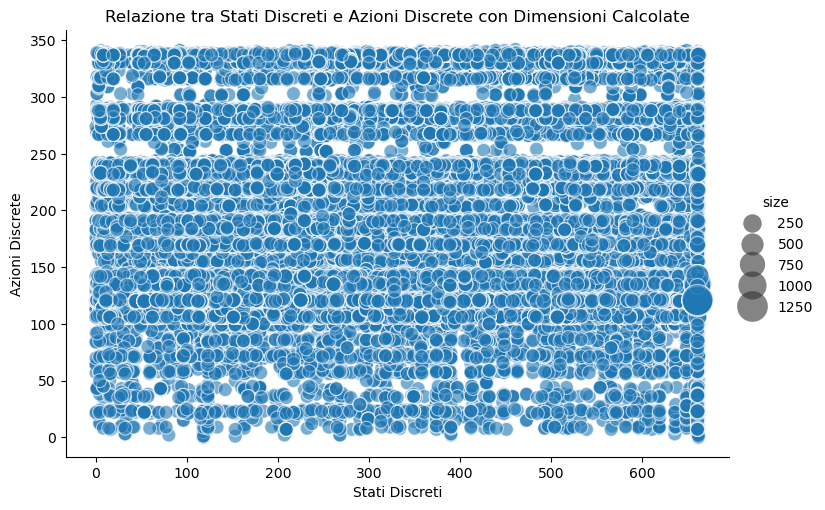

In [27]:
size_df = data.groupby(['discrete_state', 'discrete_action']).size().reset_index(name='size')

# Uniamo il DataFrame originale con le dimensioni calcolate
df = data.merge(size_df, on=['discrete_state', 'discrete_action'])

# Creiamo il grafico relazionale
sns.relplot(
    data=df, x="discrete_state", y="discrete_action",
    size="size", sizes=(100, 500),  # Modifica le dimensioni per una migliore visualizzazione
    alpha=0.6,
    height=5,
    aspect=1.5
)

plt.title('Relazione tra Stati Discreti e Azioni Discrete con Dimensioni Calcolate')
plt.xlabel('Stati Discreti')
plt.ylabel('Azioni Discrete')
plt.show()

In [109]:
from tqdm import tqdm
def peine_mc_iterate(snsasr, Qn, gamma, n_epochs=1, learning_rate=0.1, unsafety_prob=0.0, safety_map=None):
    """
    Monte-carlo-based iteration of the training procedure according to tabular FQI & Peine's supplementary discussion.
    
    snsas: numpy ndarray with discretized state-nextstate-action tuples
    r: a function that returns the immediate reward for a state-action pair
    Qn: dictionary that maps iteration indices to Qn-estimates
    n: iteration number
    gamma: discount factor
    n_epochs: number of times to iterate over dataset
    learning rate: learning rate alpha
    """
    def epoch(snsasr, Qn, gamma, learning_rate, unsafety_prob, safety_map):
        for _, (s, ns, a, er) in enumerate(snsasr):
            #print(s,a, ns)
            if unsafety_prob == 1.0:
                # We do not care about the safety rules
                Qn[s,a] = Qn[s,a] + learning_rate * (er + gamma * np.max(Qn[int(ns),:]) - Qn[s,a])
            elif unsafety_prob == 0.0:
                if safety_map[a]:
                    Qn[s,a] = Qn[s,a] + learning_rate * (er + gamma * np.max(Qn[int(ns), safety_map]) - Qn[s,a])
                else:
                    # taken action not safe, disregard sample
                    pass
            else:
                raise ValueError("Only unsafety probs in {0.0, 1.0} supported for now")
        return Qn
   
    for _ in tqdm(range(n_epochs)):
        #print(f"Epoch {n+1}")
        Qn = epoch(snsasr, Qn, gamma, learning_rate, unsafety_prob, safety_map)
        assert np.nanmax(Qn) < 100, "Scores > 100 should not occur, found: {}".format(np.nanargmax(Qn))
    return Qn

In [137]:
Qn=np.zeros((662, 7**3))
q_peine = peine_mc_iterate(
    data[['discrete_state', 'next_state', 'discrete_action', 'reward']].astype(int).to_numpy(), 
    Qn, 
    gamma=0.9, 
    unsafety_prob=1.0, 
    n_epochs=200,
    learning_rate=0.01
)

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [03:17<00:00,  1.01it/s]


In [138]:
import scipy

best_action_indices  = np.nanargmax(q_peine, axis=1)
action_index_grid = np.tile(np.array(range(7**3)), 662).reshape((662, 7**3))
best_action_grid = np.repeat(best_action_indices, 7**3).reshape((662, 7**3))
best_action_bool = best_action_grid == action_index_grid

mcp_greedy = best_action_bool.astype(float)
assert (mcp_greedy.sum(axis=1) == 1).all()

q_mcp_neg = q_peine.copy()[:n_states, :]
q_mcp_neg[q_mcp_neg == 0.0] = float('-inf')
mcp_softmax = scipy.special.softmax(q_mcp_neg , axis=1)

assert mcp_softmax.shape == (n_states, 7**3)
assert (mcp_greedy.sum(axis=1) == 1).all()

In [139]:
from config import tv_bins, fio2_bins, peep_bins,action_bin_definition
def to_discrete_action_bins(action_id, action_bin_definition=action_bin_definition):
    """
    Returns, for a given integer action_id, the corresponding bin indices for
    tv, fio2 and peep.
    """
    tv_range, fio2_range, peep_range = action_bin_definition[action_id]
    tv_bin = tv_bins.index(tv_range)
    fio2_bin = fio2_bins.index(fio2_range)
    peep_bin = peep_bins.index(peep_range)
    return tv_bin, fio2_bin, peep_bin


def to_action_ranges(action_id):
    """
    Returns, for a given action_id, the corresponding (min, max) tuples for tv,
    fio2 and peep settings.
    """
    tv_bin, fio2_bin, peep_bin = to_discrete_action_bins(action_id)
    return tv_bins[tv_bin], fio2_bins[fio2_bin], peep_bins[peep_bin]


In [140]:
best_s, best_a = np.unravel_index(np.nanargmax(q_peine), (n_states, 7**3))
print("Global highest Q value {} for tv, fio2, peep ranges: {}".format(q_peine[best_s, best_a], to_action_ranges(best_a)))
best_mean_a, best_mean_a_q = np.nanargmax(np.nanmean(q_peine, axis=0)), np.nanmax(np.nanmean(q_peine, axis=0))
print("Highest avg Q value across states {} for tv, fio2, peep ranges: {}".format(best_mean_a_q, to_action_ranges(best_mean_a)))
best_med_a, best_med_a_q = np.nanargmax(np.nanmedian(q_peine, axis=0)), np.nanmax(np.nanmedian(q_peine, axis=0))
print("Highest median Q value across states {} for tv, fio2, peep ranges: {}".format(best_med_a, to_action_ranges(best_med_a)))

Global highest Q value 9.999999999999108 for tv, fio2, peep ranges: ((0, 2.5), (35, 40), (5, 7))
Highest avg Q value across states 6.370410052999309 for tv, fio2, peep ranges: ((5, 7.5), (40, 45), (5, 7))
Highest median Q value across states 120 for tv, fio2, peep ranges: ((5, 7.5), (40, 45), (5, 7))


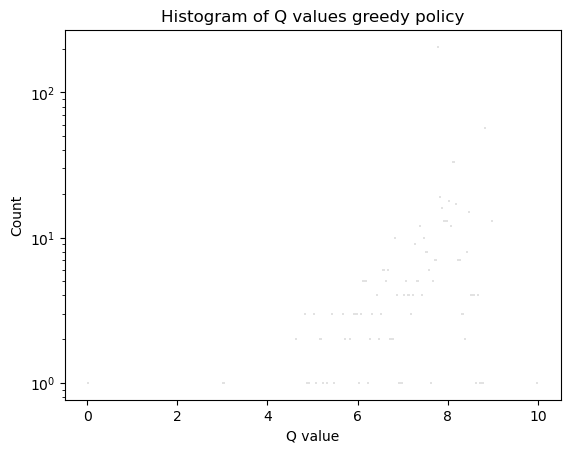

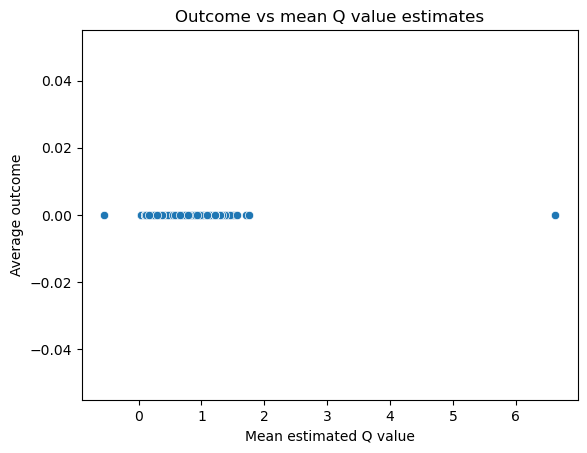

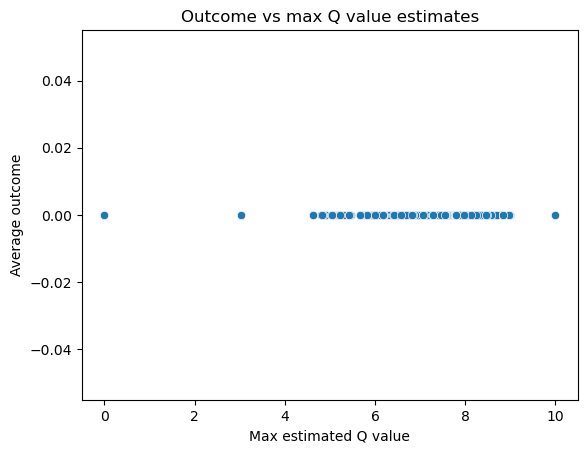

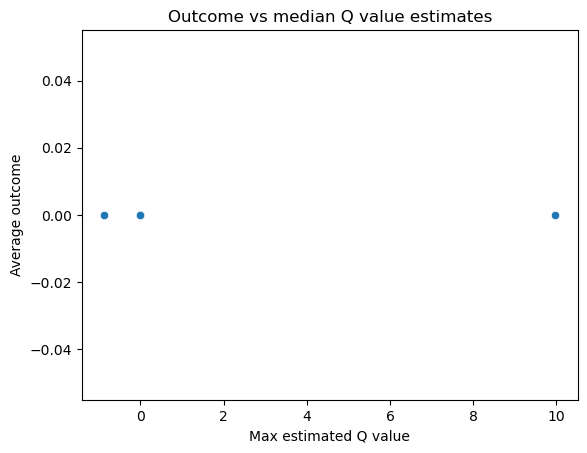

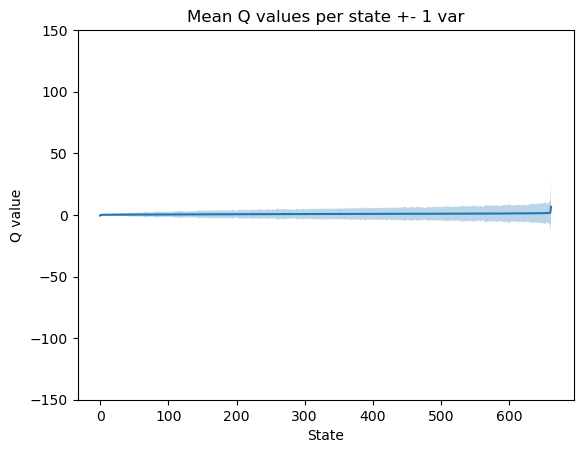

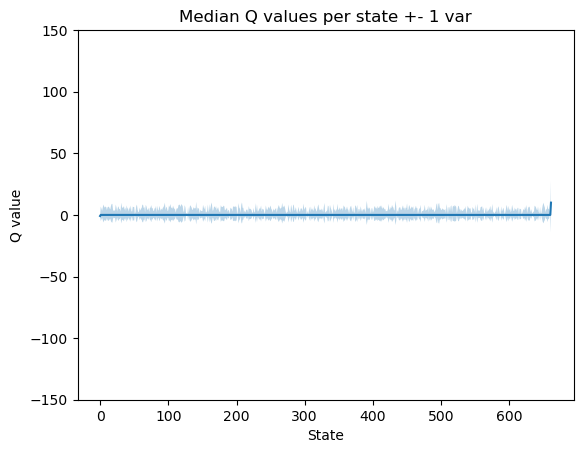

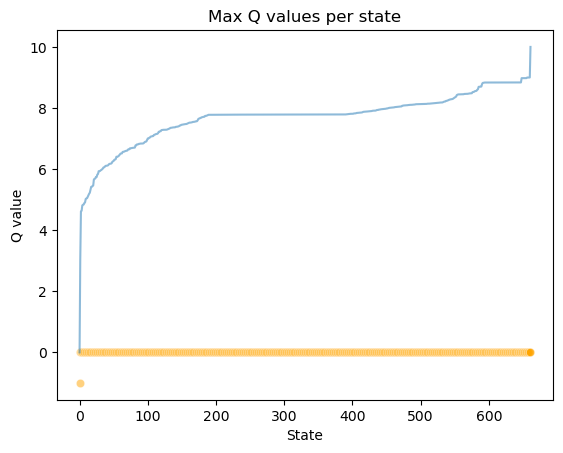

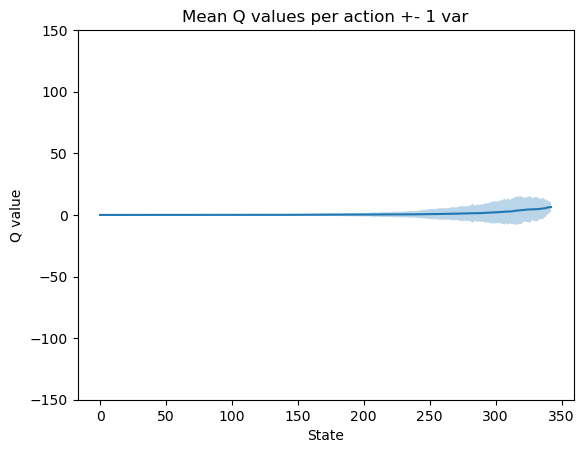

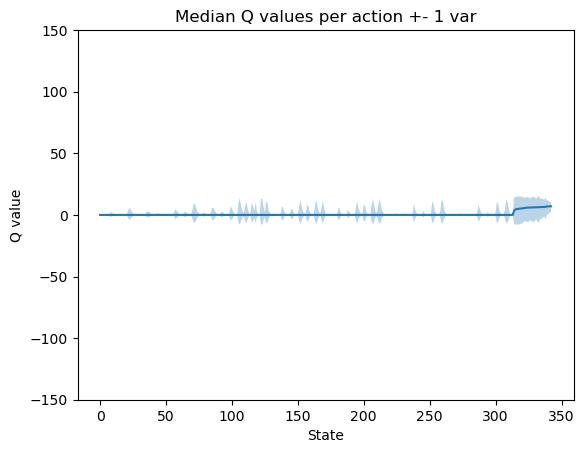

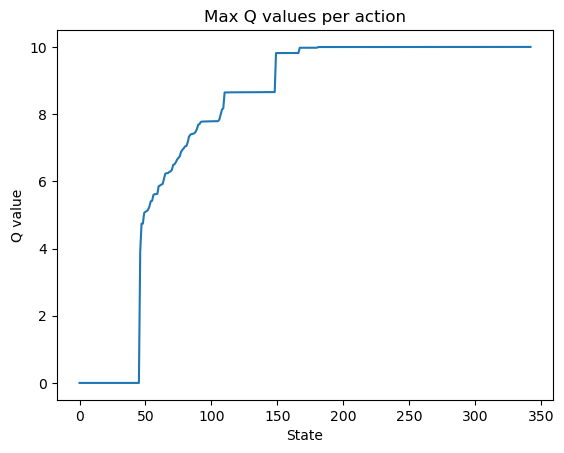

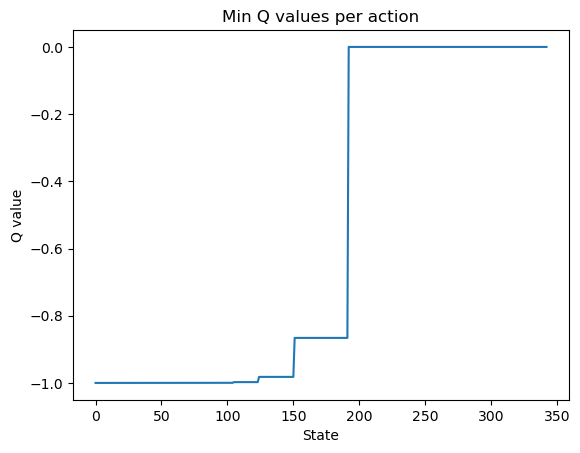

In [141]:
plot=True
def sortnan(x, index):
    return float('-inf') if np.isnan(x[index]) else x[index]
if plot:
    sns.histplot(q_peine[mcp_greedy == 1.0].ravel(), log_scale=(False, True), bins=200)
    plt.xlabel('Q value')
    plt.title('Histogram of Q values greedy policy')
    plt.show()
    
    data['positive_outcome'] = data['ep'].isin(ep_idx_succ)=='f'
    estimated_mort_state_visit = data.groupby('discrete_state').mean('positive_outcome')[['positive_outcome']].to_numpy()
    
    sns.scatterplot(x=np.nanmean(q_peine, axis=1), y=estimated_mort_state_visit.reshape(n_states,))
    plt.xlabel('Mean estimated Q value')
    plt.ylabel('Average outcome')
    plt.title('Outcome vs mean Q value estimates')
    plt.show()
    sns.scatterplot(x=np.nanmax(q_peine, axis=1), y=estimated_mort_state_visit.reshape(n_states,))
    plt.xlabel('Max estimated Q value')
    plt.ylabel('Average outcome')
    plt.title('Outcome vs max Q value estimates')
    plt.show()
    sns.scatterplot(x=np.nanmedian(q_peine, axis=1), y=estimated_mort_state_visit.reshape(n_states,))
    plt.xlabel('Max estimated Q value')
    plt.ylabel('Average outcome')
    plt.title('Outcome vs median Q value estimates')
    plt.show()
    
    q_vars = np.nanvar(q_peine, axis=1)
    q_means = np.nanmean(q_peine, axis=1)
    q_medians = np.nanmedian(q_peine, axis=1)
    q_maxs = np.nanmax(q_peine, axis=1)
    q_mins = np.nanmin(q_peine, axis=1)
    stacked = np.column_stack((q_means, q_medians, q_maxs, q_mins, q_vars))
    xs = range(n_states)
    means_sorted = np.array(sorted(stacked, key=lambda x: x[0]))
    means_upper = means_sorted[:, 0] + means_sorted[:, -1]
    means_lower = means_sorted[:, 0] - means_sorted[:, -1]
    axs = sns.lineplot(x=xs, y=means_sorted[:, 0])
    axs.fill_between(x=xs, y1=means_lower, y2=means_upper, alpha=.3)
    axs.set_ylim(-150, 150)
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Mean Q values per state +- 1 var')
    plt.show()

    medians_sorted = np.array(sorted(stacked, key=lambda x: x[1]))
    means_upper = medians_sorted[:, 0] + medians_sorted[:, -1]
    means_lower = medians_sorted[:, 0] - medians_sorted[:, -1]
    axs = sns.lineplot(x=xs, y=medians_sorted[:, 1])
    axs.fill_between(x=xs, y1=means_lower, y2=means_upper, alpha=.3)
    axs.set_ylim(-150, 150)
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Median Q values per state +- 1 var')
    plt.show()

    mins_sorted = np.array(sorted(stacked, key=lambda x: x[3]))
    axs = sns.scatterplot(x=xs, y=mins_sorted[:, 3], color='orange', alpha=.5)
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Min Q values per state')

    maxs_sorted = np.array(sorted(stacked, key=lambda x: x[2]))
    axs = sns.lineplot(x=xs, y=maxs_sorted[:, 2], alpha=.5)
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Max Q values per state')
    plt.show()

    q_vars = np.nanvar(q_peine, axis=0)
    q_means = np.nanmean(q_peine, axis=0)
    q_medians = np.nanmedian(q_peine, axis=0)
    q_maxs = np.nanmax(q_peine, axis=0)
    q_mins = np.nanmin(q_peine, axis=0)
    stacked = np.column_stack((q_means, q_medians, q_maxs, q_mins, q_vars))
    xs = range(7**3)
    means_sorted = np.array(sorted(stacked, key=lambda x: sortnan(x, 0)))
    means_upper = means_sorted[:, 0] + means_sorted[:, -1]
    means_lower = means_sorted[:, 0] - means_sorted[:, -1]
    axs = sns.lineplot(x=xs, y=means_sorted[:, 0])
    axs.fill_between(x=xs, y1=means_lower, y2=means_upper, alpha=.3)
    axs.set_ylim(-150, 150)
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Mean Q values per action +- 1 var')
    plt.show()

    medians_sorted = np.array(sorted(stacked, key=lambda x: sortnan(x, 1)))
    means_upper = medians_sorted[:, 0] + medians_sorted[:, -1]
    means_lower = medians_sorted[:, 0] - medians_sorted[:, -1]
    axs = sns.lineplot(x=xs, y=medians_sorted[:, 1])
    axs.fill_between(x=xs, y1=means_lower, y2=means_upper, alpha=.3)
    axs.set_ylim(-150, 150)
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Median Q values per action +- 1 var')
    plt.show()

    maxs_sorted = np.array(sorted(stacked, key=lambda x: sortnan(x, 2)))
    axs = sns.lineplot(x=xs, y=maxs_sorted[:, 2])
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Max Q values per action')
    plt.show()

    mins_sorted = np.array(sorted(stacked, key=lambda x: sortnan(x, 3)))
    axs = sns.lineplot(x=xs, y=mins_sorted[:, 3])
    plt.xlabel('State')
    plt.ylabel('Q value')
    plt.title('Min Q values per action')
    plt.show()

In [150]:
# behavior_policy_df = (data.value_counts(['discrete_state', 'discrete_action']) / data.value_counts(['discrete_state']))
# assert (1.0 - behavior_policy_df.groupby('discrete_state').sum() < 1e10).all(), "Policy action probs should sum to 1 per state"
# behavior_policy_df = behavior_policy_df.reset_index()

behavior_policy_df = data.value_counts(['discrete_state', 'discrete_action']) / data.value_counts(['discrete_state'])
assert (1.0 - behavior_policy_df.groupby('discrete_state').sum() < 1e10).all(), "Policy action probs should sum to 1 per state"

behavior_policy_pivot = behavior_policy_df.reset_index().pivot(columns='discrete_action', index='discrete_state')["count"]
behavior_policy_states = set(behavior_policy_pivot.index.unique())
for s in range(n_states):
    if s not in behavior_policy_states:
        action_probs = [1.0 / (7**3),] * 7**3 # uniform distribution
        for i, p in enumerate(action_probs):
            behavior_policy_pivot.loc[s] = [s, i, p]

behavior_policy_pivot = behavior_policy_pivot.sort_values(['discrete_state'])

for a in range(7**3):
    if a not in behavior_policy_pivot.columns:
        behavior_policy_pivot.loc[:, a] = np.nan

behavior_policy_nan = behavior_policy_pivot[range(7**3)].to_numpy()
assert (1- (np.nansum(behavior_policy_nan, axis=1)) < 1e10).all(), "Policy action probs should sum to 1 per state"
behavior_policy = np.nan_to_num(behavior_policy_nan, 0.0)
assert (1- (behavior_policy.sum(axis=1)) < 1e10).all(), "Policy action probs should sum to 1 per state"
assert behavior_policy.shape == (n_states, 7**3), "Behavior policy should cover all states and actions"
mcp_greedy_mask = mcp_greedy.astype(bool)
assert (mcp_greedy_mask.sum(axis=1) == 1).all(), "Greedy policy mask should mask out all-but-one action"

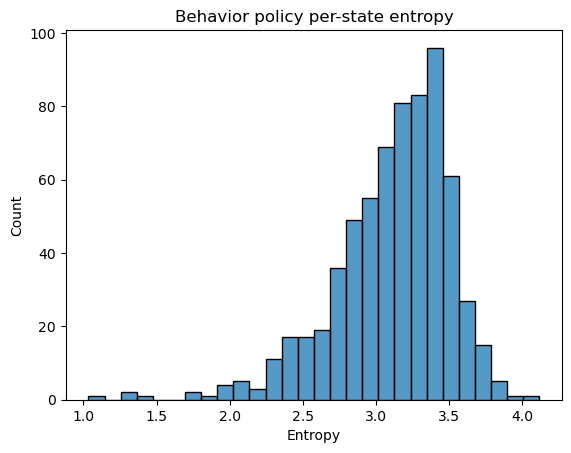

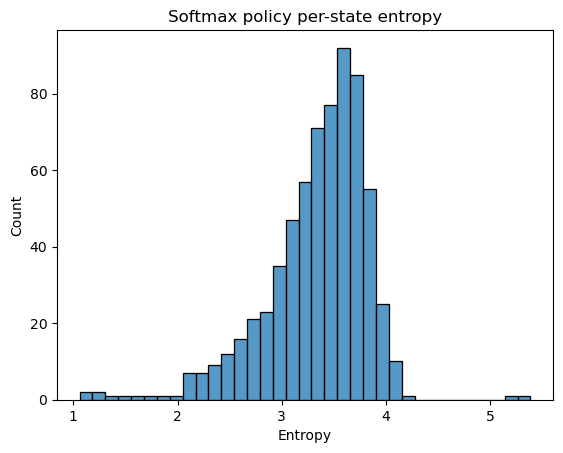

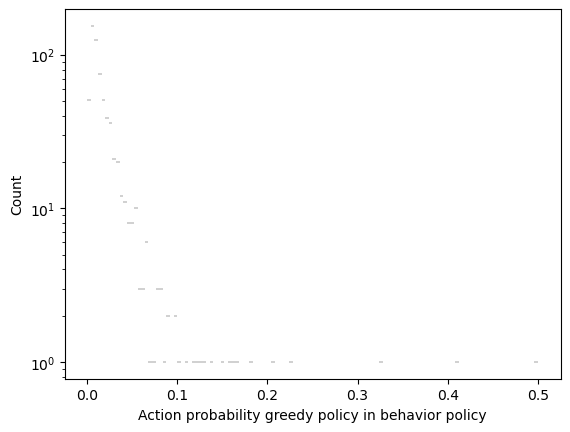

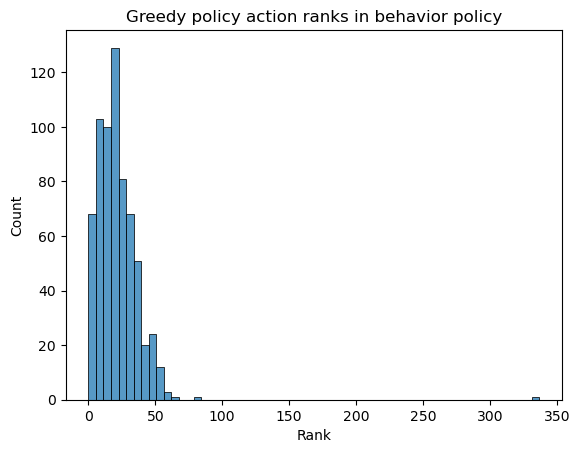

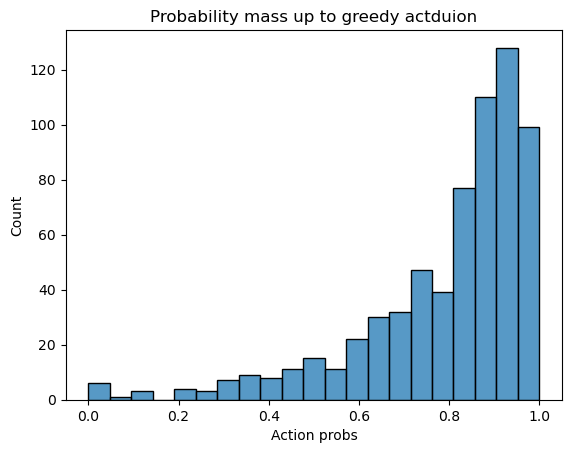

(np.float64(0.0), np.float64(0.9999999999999999))

In [151]:
sns.histplot(scipy.stats.entropy(behavior_policy, axis=1))
plt.title('Behavior policy per-state entropy')
plt.xlabel('Entropy') 
plt.show()

sns.histplot(scipy.stats.entropy(mcp_softmax, axis=1))
plt.title('Softmax policy per-state entropy')
plt.xlabel('Entropy')
plt.show()

sns.histplot(behavior_policy[mcp_greedy_mask], log_scale=(False, True))
plt.xlabel('Action probability greedy policy in behavior policy')
behavior_policy[mcp_greedy_mask].min(), behavior_policy[mcp_greedy_mask].max()
plt.show()

evaluation_policy = mcp_greedy

behavior_policy_ranks = np.flip(behavior_policy.argsort(axis=1), axis=1)
ep_bp_ranks = []
for s in range(n_states):
    ep_a = evaluation_policy[s,:].argmax()
    bp_rank = np.where(behavior_policy_ranks[s, :] == ep_a)[0][0]
    ep_bp_ranks.append(bp_rank)

sns.histplot(ep_bp_ranks, bins=60)
plt.title('Greedy policy action ranks in behavior policy')
plt.xlabel('Rank')
plt.show()

behavior_policy_ranked_probs = np.flip(np.sort(behavior_policy, axis=1), axis=1)
ep_bp_prob_mass = []
for s in range(n_states):
    ep_a = evaluation_policy[s,:].argmax()
    bp_rank = np.where(behavior_policy_ranks[s, :] == ep_a)[0][0]
    ep_bp_prob_mass.append(behavior_policy_ranked_probs[s, 0:bp_rank].sum())

sns.histplot(ep_bp_prob_mass)
plt.title('Probability mass up to greedy actduion')
plt.xlabel('Action probs')
plt.show()
np.array(ep_bp_prob_mass).min(), np.array(ep_bp_prob_mass).max()
